# 1、基础入门

## 1.1 基础langgraph, graph api流程

In [1]:
from operator import add
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END


# graph api风格
# 1、定义状态 , TypedDict 父类，字典状态
class OverAllState(TypedDict):
    # 日志类型还是 list[str], 但更新的方式不是覆盖 而是add追加
    logs: Annotated[list[str], add]
    # 当前运行的位置。当前的集合
    cur_id: str


# 2、定义节点：本质是定义一个执行的流程
# state: OverAllState 输入类型
# -> OverAllState 返回类型
# 当graph 执行到node1 会在日志添加内容，cur_id 拼接上当前id
def node_1(state: OverAllState) -> OverAllState:
    # 获取当前id
    pre_id = state["cur_id"]
    return {
        # 拼接上node1
        "cur_id": pre_id + ", node_1",
        # 日志
        "logs": ["node_1 运行完毕"],
    }


def node_2(state: OverAllState) -> OverAllState:
    # 获取当前id
    pre_id = state["cur_id"]
    return {
        # 拼接上node1
        "cur_id": pre_id + ", node_2",
        # 日志
        "logs": ["node_2 运行完毕"],
    }


# 3、定义边: 边依赖图添加内容
# 3.1 创建图，获取建造者(类似建造者模式)
builder = StateGraph(state_schema=OverAllState)
# 3.2 添加节点
builder.add_node(node_1)
builder.add_node(node_2)
# 3.3 添加边
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 4、获取图
graph = builder.compile()
# 5、运行图
# 需要传入初始的状态
result = graph.invoke({"cur_id": "start"})
print(result)


{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


# 1.2 图结构可视化

复制 graph td的内容到md文档中就可以渲染出图
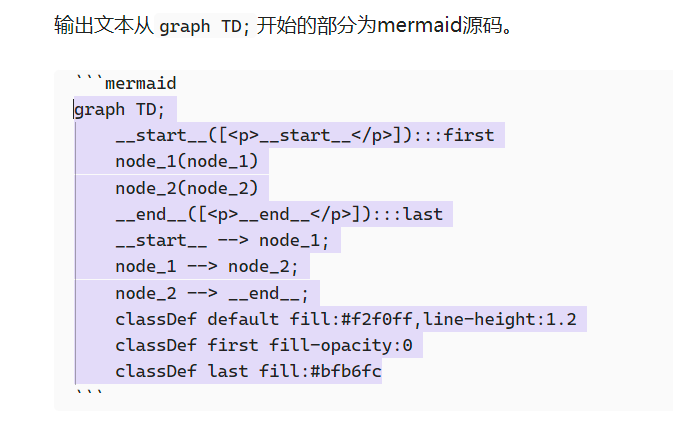
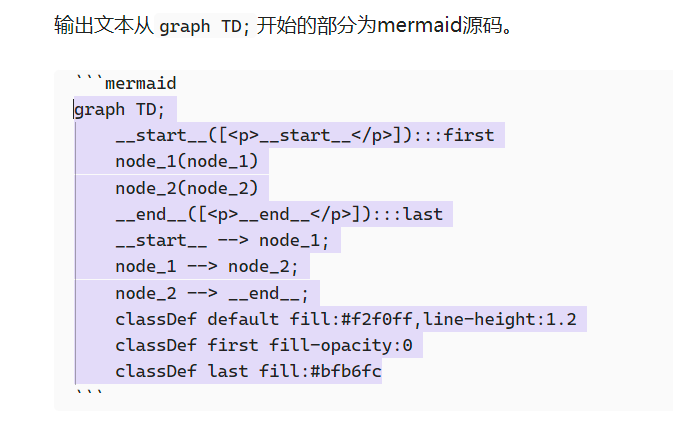

In [2]:
# 获取图的mermaid代码，可以直接在md中渲染
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



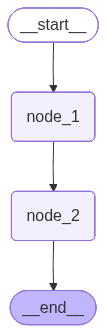

In [3]:
from IPython.display import Image, display

# get_graph 获取图，draw_mermaid_png 获取图mermaid代码
png_bytes = graph.get_graph().draw_mermaid_png()
# 转换为图片
png = Image(png_bytes)
display(png)


In [5]:
png_bytes = graph.get_graph().draw_mermaid_png()
# 打印图片数据
print(png_bytes)
# 保存为图片
png_filename = 'first_demo_graph.png'
with open(png_filename, "wb") as f:
    f.write(png_bytes)

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00j\x00\x00\x01M\x08\x02\x00\x00\x00g\x9dm\xfa\x00\x00\x10\x00IDATx\x9c\xec\x9d\t|\x13e\xde\xc7\x9f\x99$M\xef\x83\xde\xf7A[h9\xdaB\x11P\xa0r\xa3\x0b\xcba\x15,\xe0\x05\xa8\xa8\x88\x8a\xe8\xee\x0b\xeb\x8a\xc2z\xb0*xpt\x15E\xa4\xb0\x82"\x08\x8b\xa0 `\xcbU,*\x14\x8a\xd2\xd2\x83\x9e\xf4J\xdb\xa4\xb9f\xe6}&\xd3\xa6i\x9bd\x92<M\x1d\x9a\xe7+\x9f:\x99\xe7\x99g&\xbf<\xd7\xfc\x9f\xe3/f\x18\x06`lE\x0c0\x08`\xf9\x90\xc0\xf2!\x81\xe5C\x02\xcb\x87\x04\x96\x0f\tT\xf9n\xe4+\xaf\xe755\xd4\xaai\x8aQ)h\xc0\x00BD3\x14I\x90\x00\xfe\xa3)\x00\xcf\x00\x92\x01\x0c\x01\x0fDR\x86R\x11\xf0*\x12\x06\xd1\xec\xe5\x84\x98a\xb4\xec\x19\x82\x80=(]\x90\x13C\xab\xd9\x03\x98\x16L\x83\xbb\x8b>\x1a\x04\xc6"\xe1_]w\x8b\x10\x01\x86\xd6%\x0e\xd8\xdb10M\x82\xfdH\x88\x01\xa3m\x7fD\x92\xbd\x08\xd0\x84\xfe\x99ERB*%\xdd\xbc$\x91\t\xae\x83F{\x00\x04\x08\xdb\xfa}y\xc7e\x97r\x1a[dZ\xf8\xb4b\t!\x96\x92\xce\xae$E1\x0c\xc5\xb0_\x89b\xbf\x0c)"\xa0\xa6\xf0+\x11$\xab\x1d\xbc\x91HJR*V6RL\xd0Z\xf6

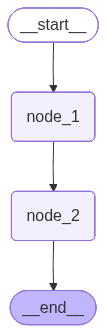

In [7]:
# 快捷使用方法，直接展示图
from IPython.display import display

display(graph)
